In [1]:
pip install PyPortfolioOpt

  Using cached pyportfolioopt-1.5.6-py3-none-any.whl.metadata (22 kB)
  Using cached cvxpy-1.8.1-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached ecos-2.0.14.tar.gz (142 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached plotly-5.24.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached scipy-1.17.0-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached osqp-1.1.0-cp313-cp313-win_amd64.whl.metadata (2.1 kB)
  Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached scs-3.2.11-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached highspy-1.13.0-cp313-cp313-win_amd64.whl.metadata (11 kB)


  error: subprocess-exited-with-error
  
  × Building wheel for ecos (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      C:\Users\julia\AppData\Local\Temp\pip-build-env-6hwkz8va\overlay\Lib\site-packages\setuptools\_distutils\dist.py:287: UserWarning: Unknown distribution option: 'tests_require'
        warnings.warn(msg)
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-313\ecos
      copying src\ecos\ecos.py -> build\lib.win-amd64-cpython-313\ecos
      copying src\ecos\version.py -> build\lib.win-amd64-cpython-313\ecos
      copying src\ecos\__init__.py -> build\lib.win-amd64-cpython-313\ecos
      running build_ext
      building '_ecos' extension
      error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/
      [end of output]
  
  note: This error originates from a subprocess, 

In [6]:
import pandas as pd
from pypfopt import EfficientFrontier, risk_models, expected_returns

#Baixando a matriz de dados
df_precos = pd.read_csv("matriz_final_v3_survivorship.csv", index_col="Date", parse_dates=True)

#Definindo 20% dos dados para teste
split_idx = int(len(df_precos) * 0.8)
df_teste = df_precos.iloc[split_idx:]

#Configurando a janela móvel para atribuir pesos para cada dia
janela = 63
lista_pesos = []

#Loop para calcular os pesos de cada dia da janela móvel
for i in range(len(df_teste)):
    #Localizando o tempo
    idx_fim = split_idx + i
    #Pegando o histórico imediatamente anterior
    historico = df_precos.iloc[idx_fim - janela : idx_fim]

    try:
        #Retornos médios e Matriz de covariância
        mu = expected_returns.mean_historical_return(historico)
        S = risk_models.sample_cov(historico)
        
        #Otimizando para Mínima Volatilidade (Markowitz de baixo risco)
        ef = EfficientFrontier(mu, S)
        pesos_brutos = ef.min_volatility() 
        
        #Limpando valores insignificantes nos pesos
        pesos_limpos = ef.clean_weights()
        lista_pesos.append(pesos_limpos)
        
    except Exception as e:
        #Caso a matemática falhe em algum dia, repetimos o peso anterior
        print(f"Erro no dia {df_teste.index[i]}: {e}")
        lista_pesos.append(lista_pesos[-1] if lista_pesos else {})


#Salvando o resultado
df_markowitz = pd.DataFrame(lista_pesos, index=df_teste.index)
df_markowitz.to_csv("pesos_markowitz_final.csv")

c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning: The covariance matrix is non positive semidefinite. Amending eigenvalues.
  warnings.warn(
c:\Ana\Lib\site-packages\pypfopt\risk_models.py:70: UserWarning:

In [1]:
# Métricas na Estratégia de Markowitz

import pandas as pd
import numpy as np

#Carregando os preços e os pesos de markowitz
df_precos = pd.read_csv("matriz_final_v3_survivorship.csv", index_col="Date", parse_dates=True)
df_pesos = pd.read_csv("pesos_markowitz_final.csv", index_col="Date", parse_dates=True)

df_retornos = df_precos.pct_change().dropna()
retornos_teste = df_retornos.loc[df_pesos.index]

#Calculando performance diária
retorno_portfólio = (df_pesos * retornos_teste).sum(axis=1)
curva_patrimonio = (1 + retorno_portfólio).cumprod()


risk_free_rate = 0.0422

#Retorno Anualizado
annual_return_mk = retorno_portfólio.mean() * 252

#Volatilidade Anualizada
volatility_mk = retorno_portfólio.std() * np.sqrt(252) 

#Sharpe Ratio
sharpe_ratio_mk = (annual_return_mk - risk_free_rate) / volatility_mk 

#Máximo Drawdown
cum_max_mk = curva_patrimonio.cummax()
drawdown_mk = curva_patrimonio / cum_max_mk - 1
max_drawdown_mk = drawdown_mk.min()


print(f"Retorno anualizado: {annual_return_mk:.2%}")
print(f"Volatilidade anualizada: {volatility_mk:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio_mk:.2f}")
print(f"Máximo Drawdown: {max_drawdown_mk:.2%}")

Retorno anualizado: 1.12%
Volatilidade anualizada: 12.45%
Sharpe Ratio: -0.25
Máximo Drawdown: -10.58%


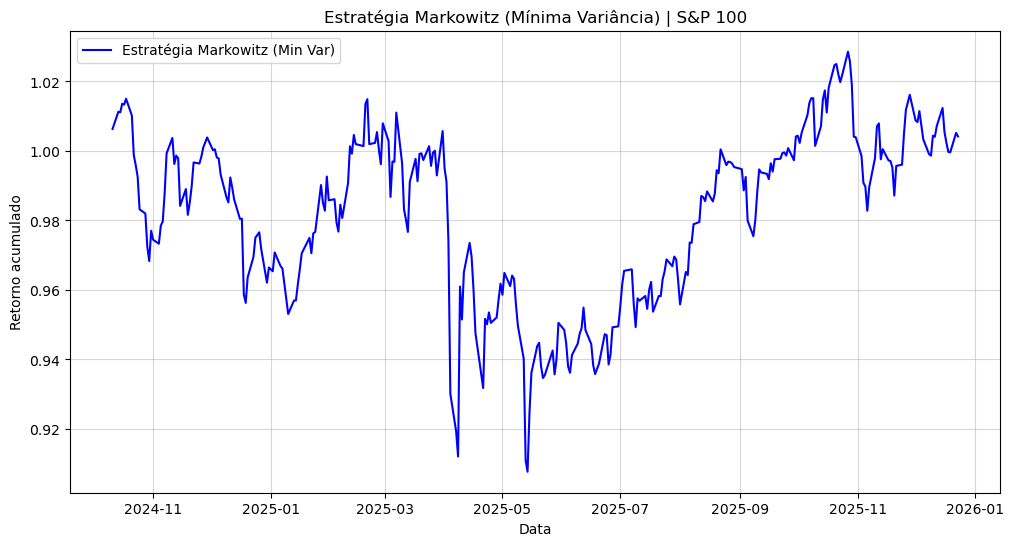

Retorno Final: 1.00


In [4]:
#Representação Gráfica dos Retornos

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(curva_patrimonio, label='Estratégia Markowitz (Min Var)', color='blue', linewidth=1.5)

plt.title('Estratégia Markowitz (Mínima Variância) | S&P 100', fontsize=12)
plt.xlabel('Data')
plt.ylabel('Retorno acumulado')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.5)

plt.savefig("grafico_markowitz.png")
plt.show()

print(f"Retorno Final: {curva_patrimonio.iloc[-1]:.2f}")